<a href="https://colab.research.google.com/github/mandalpsm/Knowledgegraph_2/blob/main/lisjkg_Spacy_transformer1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q spacy transformers torch networkx matplotlib pandas openpyxl
!pip install -q spacy-transformers
!python -m spacy download en_core_web_trf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 769.9/769.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.5/313.5 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import spacy
from spacy import displacy
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from google.colab import files
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


Libraries imported successfully!


In [4]:
uploaded = files.upload()

Saving kg_dataset.xlsx to kg_dataset.xlsx


In [5]:
df = pd.read_excel("kg_dataset.xlsx")

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 3 records:")
df.head(3)

Dataset shape: (27825, 13)

Column names:
['Cites', 'Authors', 'Title', 'Year', 'Source', 'Publisher', 'Place', 'Country', 'ArticleURL', 'DOI', 'ISSN', 'Keywords', 'Abstract']

First 3 records:


,Cites,Authors,Title,Year,Source,Publisher,Place,Country,ArticleURL,DOI,ISSN,Keywords,Abstract
0,18,Patit Paban Santra; Debasis Majhi,Scholarly Communication and Machine-Generated ...,2023,Journal of Information and Knowledge,Sarada Ranganathan Endowment for Library Scien...,Bangalore,India,https://doi.org/10.17821/srels/2023/v60i3/171028,10.17821/srels/2023/v60i3/171028,2583-9314,language model;AI model; AI writing; AI writin...,This study utilizes GPT (Generative Pre-Traine...
1,8,Bolaji David Oladokun; Joel Eleojo Aruwa; Gabr...,Misinformation and Disinformation in the Era o...,2024,Journal of Information and Knowledge,Sarada Ranganathan Endowment for Library Scien...,Bangalore,India,https://doi.org/10.17821/srels/2024/v61i1/171266,10.17821/srels/2024/v61i1/171266,2583-9314,Fact-Checking Skills; Misinformation; Social M...,The paper explores the need for fact-checking ...
2,8,Manoj Kumar Verma; Mayank Yuvaraj,AI-Based Literature Reviews: A Topic Modeling ...,2023,Journal of Information and Knowledge,Sarada Ranganathan Endowment for Library Scien...,Bangalore,India,https://doi.org/10.17821/srels/2023/v60i2/170967,10.17821/srels/2023/v60i2/170967,2583-9314,Topic Modelling; Conducting Literature Reviews...,The purpose of this paper is to highlight the ...


In [6]:
# Combine Title + Abstract for richer context
df['text'] = df['Title'].fillna('') + ". " + df['Abstract'].fillna('')

# Remove empty texts
df = df[df['text'].str.len() > 50].reset_index(drop=True)

print(f"Number of usable records: {len(df)}")
print("\nSample text:")
print(df['text'][0][:500])

Number of usable records: 27781

Sample text:
Scholarly Communication and Machine-Generated Text: Is it Finally AI vs AI in Plagiarism Detection?. This study utilizes GPT (Generative Pre-Trained Transformer) language model-based AI writing tools to create a set of 80 academic writing samples based on the eight themes of the experiential sessions of the LTC 2023. These samples, each between 2000 and 2500 words long, are then analyzed using both conventional plagiarism detection tools and selected AI detection tools. The study finds that trad


In [7]:
nlp = spacy.load("en_core_web_trf")
print("spaCy Transformer model loaded successfully!")
print("Pipeline:", nlp.pipe_names)

spaCy Transformer model loaded successfully!
Pipeline: ['transformer', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [8]:
def extract_entities(text):
    doc = nlp(text)
    entities = []
    for ent in doc.ents:
        entities.append({
            "text": ent.text.strip(),
            "label": ent.label_
        })
    return entities, doc

# Test on first record
sample_text = df['text'][0]
entities, doc = extract_entities(sample_text)

print("Extracted Entities:")
for ent in entities:
    print(f"  • {ent['text']} → {ent['label']}")

Extracted Entities:
  • 80 → CARDINAL
  • eight → CARDINAL
  • the LTC 2023 → ORG
  • between 2000 and 2500 → CARDINAL
  • an era → DATE


In [9]:
displacy.render(doc, style="ent", jupyter=True)

In [10]:
def extract_relations(doc):
    """
    Simple dependency-based relation extraction.
    Suitable as a starting point for LIS literature.
    """
    relations = []

    for token in doc:
        if token.dep_ in ("nsubj", "nsubjpass") and token.head.pos_ == "VERB":
            subject = " ".join([t.text for t in token.subtree if t.dep_ in ("compound", "amod") or t == token])
            verb = token.head.lemma_

            for child in token.head.children:
                if child.dep_ in ("dobj", "attr", "pobj"):
                    obj = " ".join([t.text for t in child.subtree if not t.is_punct])
                    relations.append((subject.strip(), verb, obj.strip()))

                if child.dep_ == "prep":
                    for gc in child.children:
                        if gc.dep_ == "pobj":
                            obj = " ".join([t.text for t in gc.subtree if not t.is_punct])
                            relations.append((subject.strip(), f"{verb}_{child.text}", obj.strip()))

    # Remove very short or noisy triples
    cleaned = []
    for s, r, o in relations:
        if len(s) > 2 and len(o) > 2 and s.lower() != o.lower():
            cleaned.append((s, r, o))

    return cleaned

In [11]:
relations = extract_relations(doc)
print("Extracted Relations:")
for rel in relations:
    print(f"  ({rel[0]}) —[{rel[1]}]→ ({rel[2]})")

Extracted Relations:
  (study) —[utilize]→ (GPT Generative Pre Trained Transformer language model based AI writing tools)
  (traditional syntactic based anti - plagiarism tools) —[struggle_due]→ (the differences in syntax and structure between machine generated and human written text)
  (AI detectors) —[use_in]→ (which)
  (research) —[shed]→ (light)
  (research) —[shed_on]→ (the challenges associated with AI generated content in the academic research literature)


In [12]:
def build_knowledge_graph(dataframe, max_records=50):
    """
    Build a Knowledge Graph from the dataset.
    max_records is used to control processing time in Colab.
    """
    G = nx.DiGraph()
    all_triples = []

    for idx, row in dataframe.head(max_records).iterrows():
        text = row['text']
        doc = nlp(text)

        # Add entities as nodes
        for ent in doc.ents:
            node_name = ent.text.strip()
            if len(node_name) > 2:
                G.add_node(node_name, label=ent.label_)

        # Add relations as edges
        relations = extract_relations(doc)
        for subj, pred, obj in relations:
            G.add_edge(subj, obj, relation=pred)
            all_triples.append({
                "Subject": subj,
                "Relation": pred,
                "Object": obj,
                "Source_Title": row.get('Title', ''),
                "Year": row.get('Year', '')
            })

    return G, all_triples

# Build the graph (start with 30–50 records for testing)
G, triples = build_knowledge_graph(df, max_records=30)

print(f"Knowledge Graph created successfully!")
print(f"Number of Nodes : {G.number_of_nodes()}")
print(f"Number of Edges : {G.number_of_edges()}")
print(f"Number of Triples: {len(triples)}")

Knowledge Graph created successfully!
Number of Nodes : 555
Number of Edges : 261
Number of Triples: 261


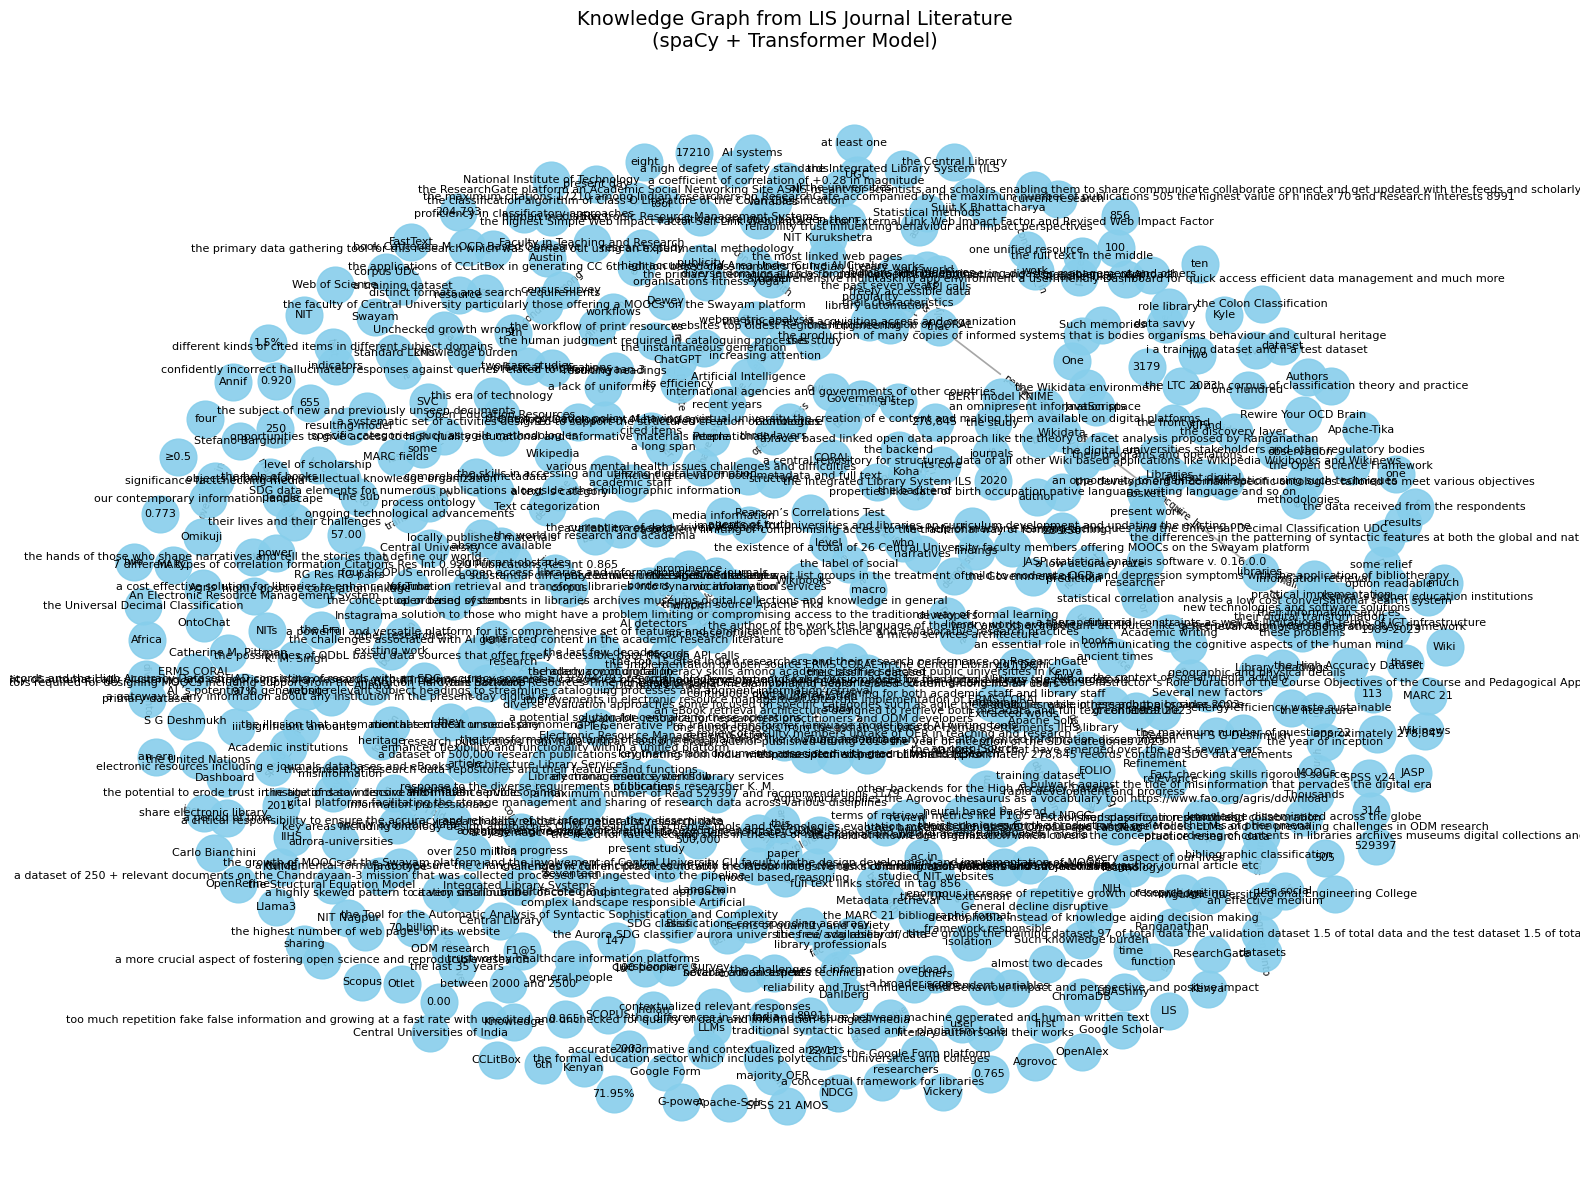

In [13]:
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=0.45, iterations=40, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=700, node_color="#87CEEB", alpha=0.9)
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=12, edge_color="gray", width=1.2, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=8)

edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

plt.title("Knowledge Graph from LIS Journal Literature\n(spaCy + Transformer Model)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
# Create DataFrame of triples
df_triples = pd.DataFrame(triples)
print(df_triples.head(10))

# Save as CSV
df_triples.to_csv("LIS_Knowledge_Graph_Triples.csv", index=False)
print("\nTriples exported to: LIS_Knowledge_Graph_Triples.csv")

                                             Subject      Relation  \
0                                              study       utilize   
1  traditional syntactic based anti - plagiarism ...  struggle_due   
2                                       AI detectors        use_in   
3                                           research          shed   
4                                           research       shed_on   
5                                              paper       explore   
6                                              paper        employ   
7                    significance factchecking media  overstate_in   
8                          information professionals          hold   
9               Fact checking skills rigorous source      stand_as   

                                              Object  \
0  GPT Generative Pre Trained Transformer languag...   
1  the differences in syntax and structure betwee...   
2                                              which   
3    

In [15]:
cypher_commands = []

for _, row in df_triples.iterrows():
    subj = str(row['Subject']).replace('"', "'")
    obj  = str(row['Object']).replace('"', "'")
    rel  = str(row['Relation']).replace(" ", "_").replace("-", "_").upper()

    cypher = f'MERGE (a:Entity {{name: "{subj}"}}) MERGE (b:Entity {{name: "{obj}"}}) MERGE (a)-[:{rel}]->(b);'
    cypher_commands.append(cypher)

with open("import_to_neo4j.cypher", "w", encoding="utf-8") as f:
    f.write("\n".join(cypher_commands))

print("Cypher file created: import_to_neo4j.cypher")
print("You can copy and paste these commands into Neo4j Desktop Browser.")

Cypher file created: import_to_neo4j.cypher
You can copy and paste these commands into Neo4j Desktop Browser.
